# Actividad final
## Microcredencial en Ciencia de Datos — Universidad de Oviedo

**Objetivo**: Ejecutar el pipeline completo de análisis y preparación de datos sobre un caso real, documentando cada decisión.  
**Dataset**: HR_Data_Analysis_Prediction (`aug_train.csv`) — 19158 predicciones. Un análisis breve de las causas que pueden llevan a que los empleados busquen abandonar la empresa tras completar la formación.   
**Variable objetivo**: `target` — siendo 1 que busque abandonar y 0 que no.  

---

## Índice
0. **Carga de librerías**.
1. **Carga y exploración inicial**
2. **Análisis exploratorio univariado**
3. **Análisis exploratorio bivariado**
4. **Tratamiento de outliers**
5. **Imputación de valores perdidos**
6. **Tratamiento de variables categóricas**
---

> **Cómo leer este notebook**: Cada sección comienza con una explicación en texto de **qué vamos a hacer** y **por qué**. Después viene el código. Al final de cada sección hay una celda de conclusiones. No ejecutes el código antes de leer el texto — el análisis es tan importante como el resultado.

---
## 0. Carga de librerías

Importamos todas las librerías que necesitamos. Usamos `warnings.filterwarnings('ignore')` para no contaminar la salida del notebook con avisos de deprecación — en producción lo quitaríamos.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

---
## 1. Carga y exploración inicial

### ¿Qué hacemos aquí?
Antes de hacer nada con los datos, necesitamos responder cuatro preguntas básicas:
1. **¿Cuántas filas y columnas tiene el dataset?** — escala del problema
2. **¿Qué tipo tiene cada variable?** — determina qué operaciones son aplicables
3. **¿Hay valores perdidos?** — dónde están y cuántos
4. **¿Qué rango de valores tiene cada variable?** — detectar si los números tienen sentido

### ¿Por qué es importante?
Un error muy común es empezar a transformar datos sin haberlos entendido. El resultado es transformaciones incorrectas que introducen errores silenciosos — el código corre sin error pero los datos están mal.

In [93]:
data = pd.read_csv("data/aug_train.csv")
print(f'Dimensiones: {data.shape}')
print(f'Columnas: {list(data.columns)}')
data.head()

Dimensiones: (19158, 14)
Columnas: ['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [94]:
print(data.dtypes)

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object


**Observación**: Muchas variable de tipo `object` (texto). Pocas numéricas. Destacar que enrolled_id es un identificador y *target* es binaria (0/1). Esto determina que tendremos que aplicar codificación (OHE) a a las de tipo object, mientras que las numéricas pueden entrar directamente (tras limpieza).

=== VALORES FALTANTES POR COLUMNA ===
                     nulos  porcentaje
company_type          6140       32.05
company_size          5938       30.99
gender                4508       23.53
major_discipline      2813       14.68
education_level        460        2.40
last_new_job           423        2.21
enrolled_university    386        2.01
experience              65        0.34


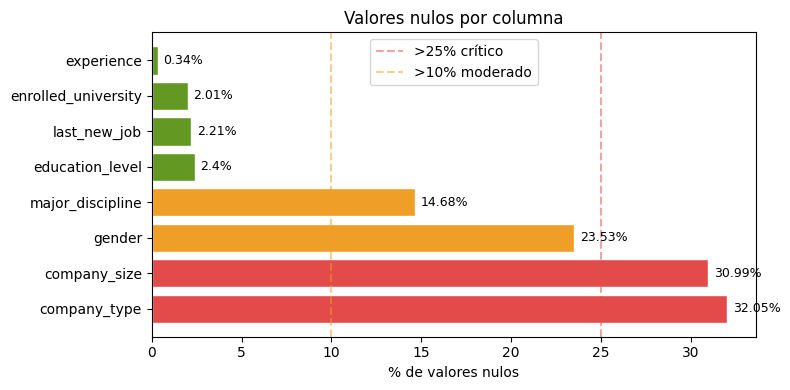

In [95]:
# ─── Diagnóstico de valores faltantes ─────────────────────────────────────────
# Contamos cuántos NaN tiene cada columna y calculamos su porcentaje.
# Ordenamos de mayor a menor para ver rápidamente cuáles son las más afectadas.
# Variables con >50% de faltantes requieren decisiones cuidadosas:
# ¿imputar, eliminar la columna, o crear un indicador de missingness?

missing = pd.DataFrame({
    'nulos': data.isnull().sum(),
    'porcentaje': (data.isnull().sum() / len(data) * 100).round(2)
}).query('nulos > 0').sort_values('porcentaje', ascending=False)

print('=== VALORES FALTANTES POR COLUMNA ===')
print(missing[missing['nulos'] > 0].to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E24B4A' if p > 25 else '#EF9F27' if p > 10 else '#639922'
          for p in missing['porcentaje']]
bars = ax.barh(missing.index, missing['porcentaje'], color=colors, edgecolor='white')
ax.set_xlabel('% de valores nulos')
ax.set_title('Valores nulos por columna')
ax.axvline(x=25, color='#E24B4A', linestyle='--', alpha=0.5, label='>25% crítico')
ax.axvline(x=10, color='#EF9F27', linestyle='--', alpha=0.5, label='>10% moderado')
for bar, pct in zip(bars, missing['porcentaje']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

graficos horizontales bien???

**Observación**: Varias variables con valores perdidos. Ahora sabemos que existe el problema. 
Revisar en la sección Imputación de valores perdidos decidiremos cómo imputarlo con información extra que obtendremos del EDA.

mayor de 25 crítico???

In [96]:
data.describe().round(2)

,enrollee_id,city_development_index,training_hours,target
count,19158.00,19158.00,19158.00,19158.00
mean,16875.36,0.83,65.37,0.25
std,9616.29,0.12,60.06,0.43
min,1.00,0.45,1.00,0.00
25%,8554.25,0.74,23.00,0.00
50%,16982.50,0.90,47.00,0.00
75%,25169.75,0.92,88.00,0.00
max,33380.00,0.95,336.00,1.00


Decir algo de las object???

**Puntos clave del resumen descriptivo:**

1. **`training_hours` — máximo de 336.00**: No tiene porque estar mal, puede ser que los empleados necesiten esas horas de formación. Eso sí, nos dara una distribución muy sesgada hacia la derecha

Decir algo del resto???

---
## 2. Análisis exploratorio univariado

### ¿Qué hacemos aquí?
Analizamos cada variable por separado. El objetivo es entender:
- **La forma de la distribución**: ¿simétrica? ¿asimétrica? ¿bimodal?
- **La presencia de outliers**: ¿hay valores extremos que se alejan mucho del grueso?
- **La distribución de la variable categórica**: ¿están bien balanceadas las categorías?

### ¿Por qué es importante?
La forma de la distribución determina qué transformaciones son apropiadas. Una distribución muy asimétrica puede perjudicar a ciertos modelos (la regresión lineal asume que los residuos son normales). Los outliers extremos distorsionan el escalado y afectan al entrenamiento.

**Excluimos `enrolle_id` y `target`** de los histogramas y boxplots.

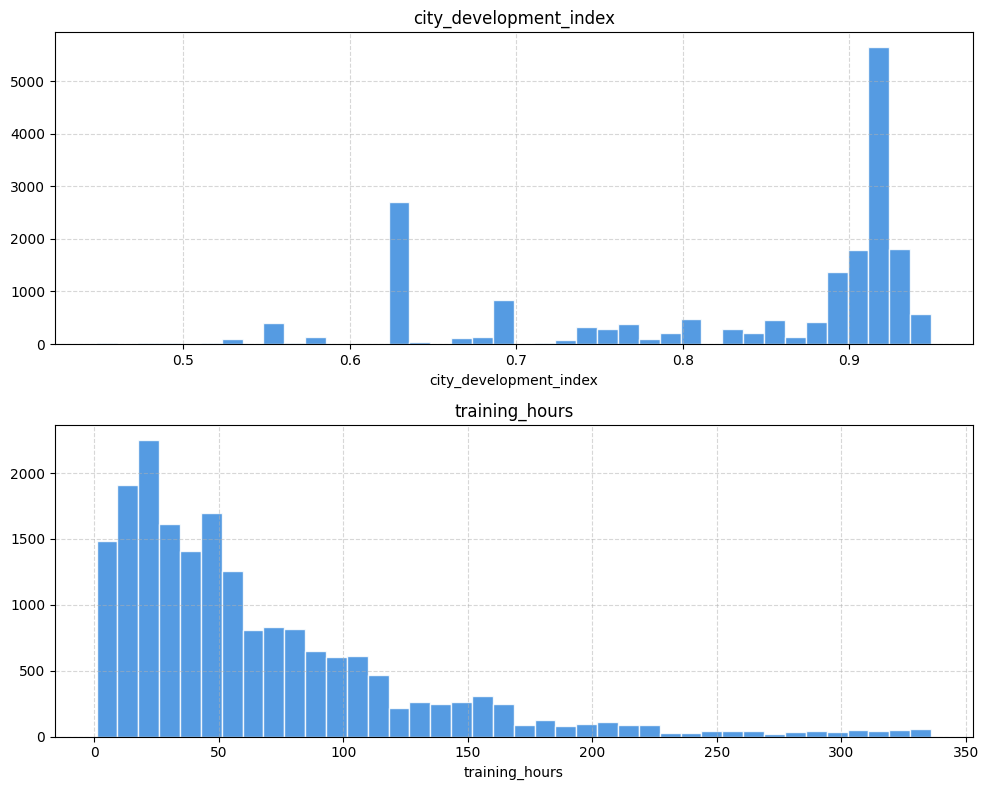

In [97]:
num_vars = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for i, var in enumerate(num_vars):
    axes[i].hist(
        data[var].dropna(),
        bins=40,
        color='#378ADD',
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'{var}')
    axes[i].set_xlabel(var)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Observaciones de los histogramas:**
- city development index muy variada de 0,5-1. Pico alto > 06 y muy alto >0.9
- training hours Distribución asimétrica moderada, con cola a la derecha.

Decir algo más???

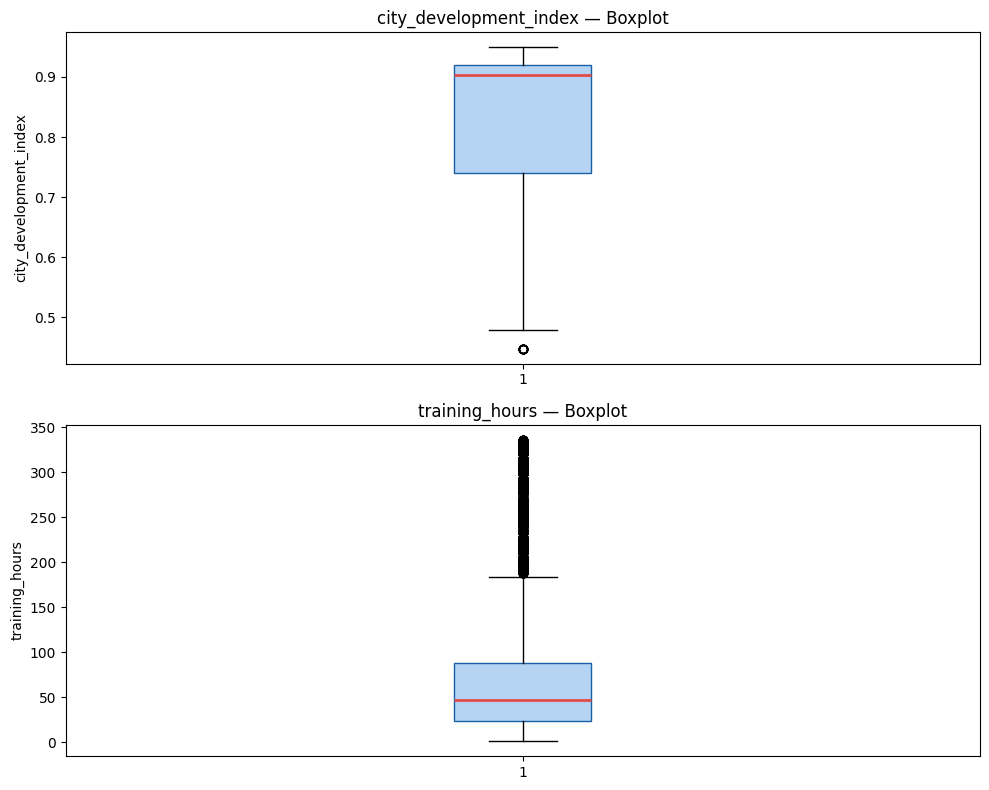

In [98]:
num_vars = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for i, var in enumerate(num_vars):
    # Boxplot
    axes[i].boxplot(data[var].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                       medianprops=dict(color='#E24B4A', linewidth=2))
    axes[i].set_title(f'{var} — Boxplot')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

Observaciones de los boxplots:

- city_development_index:  La caja (P25–P75) es grande, tiene outlier hacia abajo.
- training hours: La caja (P25–P75) es pequeña pero hay una cola enorme hacia arriba. Los puntos son outliers visuales. Estos valores extremos distorsionarán el escalado y pueden afectar al entrenamiento — los trataremos en la sección *Tratamiento de outliers*.

Está bien???

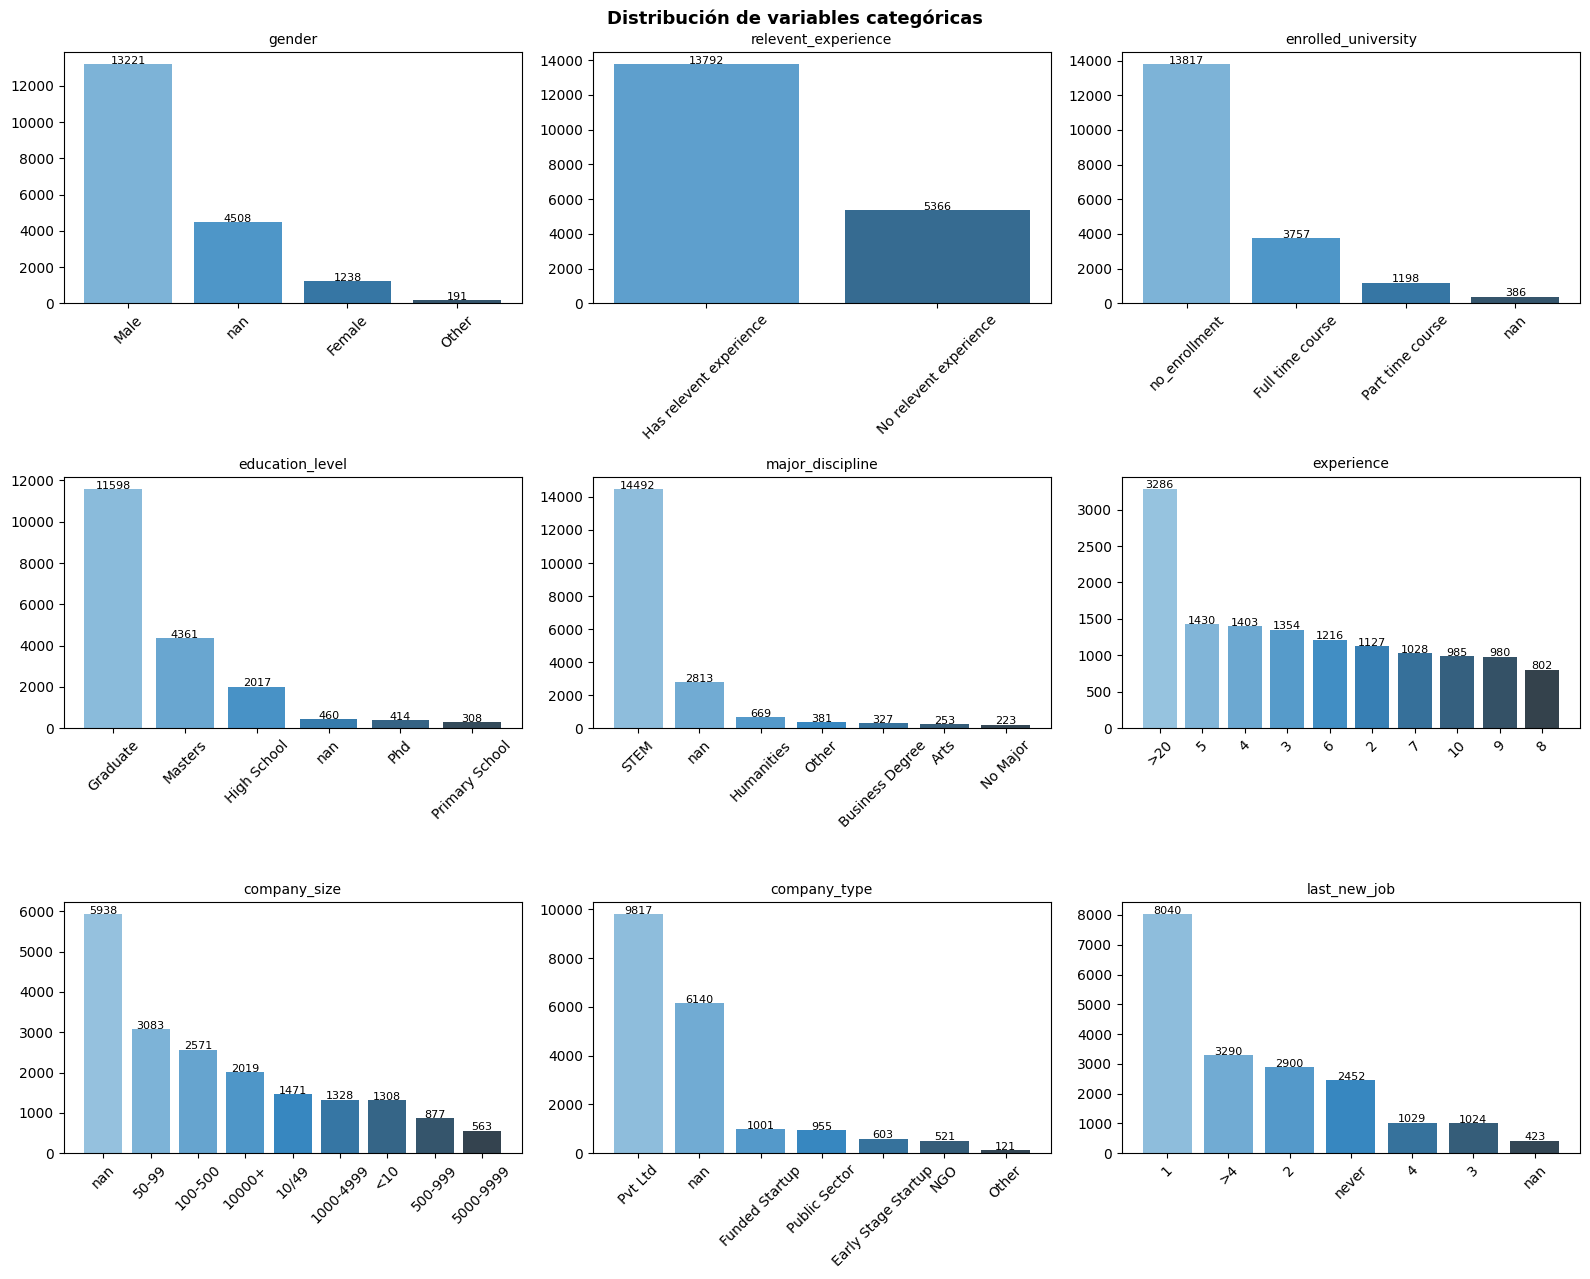

In [99]:
cat_vars = [
    'gender', 'relevent_experience', 'enrolled_university',
    'education_level', 'major_discipline', 'experience',
    'company_size', 'company_type', 'last_new_job'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    counts = data[var].value_counts(dropna=False).head(10)
    colors = sns.color_palette('Blues_d', len(counts))

    axes[i].bar(counts.index.astype(str), counts.values, color=colors)
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

    # Etiquetas encima de cada barra
    for j, (val, name) in enumerate(zip(counts.values, counts.index.astype(str))):
        axes[i].text(j, val + 5, str(val), ha='center', fontsize=8)

plt.suptitle('Distribución de variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

???

---
## 3. Análisis exploratorio bivariado

### ¿Qué hacemos aquí?
Analizamos las relaciones entre pares de variables, con foco especial en la relación de cada variable con **target**?. Los análisis bivariados incluyen:
- **Matriz de correlaciones de Pearson**: para variables numéricas
- **Boxplots del target por categorías**: ???
- **Test de Kruskal-Wallis**: para contrastar estadísticamente si las diferencias entre categorías son significativas

### ¿Por qué es importante?
Las correlaciones nos indican qué variables tienen relación lineal con el target — señal de que serán predictores útiles. También detectamos **multicolinealidad** entre predictores (variables que miden lo mismo), lo que motivará la creación de ratios en el feature engineering.

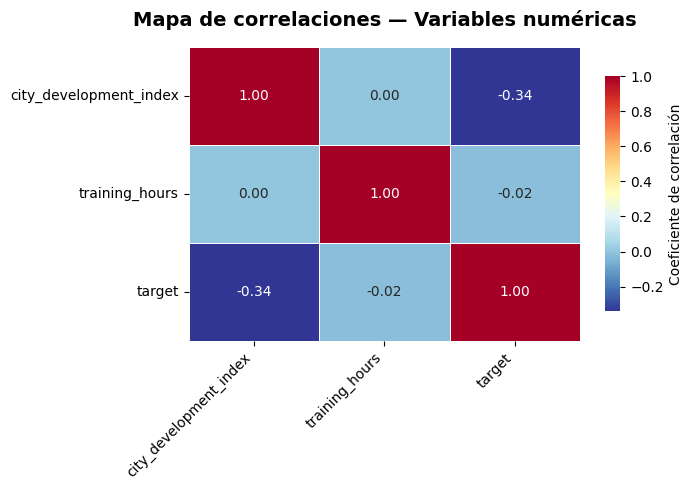

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

num_data = data[['city_development_index', 'training_hours', 'target']].copy()
corr_matrix = num_data.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",          # paleta más equilibrada
    linewidths=0.5,           # líneas divisorias suaves
    cbar_kws={'shrink': 0.8, 'aspect': 15, 'label': 'Coeficiente de correlación'}
)

plt.title('Mapa de correlaciones — Variables numéricas', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()



ordinales???

añadir de donde saco los estilos???

**Lecturas clave de la matriz de correlaciones:**


Con el target:
- city_development_index	−0.34	. Correlación negativa moderada. A medida que el índice de desarrollo de la ciudad aumenta, la probabilidad de que el target sea positivo (buscar trabajo) tiende a disminuir.
- training_hours	−0.02	. Prácticamente nula. Las horas de entrenamiento no parecen influir en el target.

- **`city_development_index`** y **`training_hours`** tienen baja correlación entre sí → son dimensiones independientes de información.

Representación???

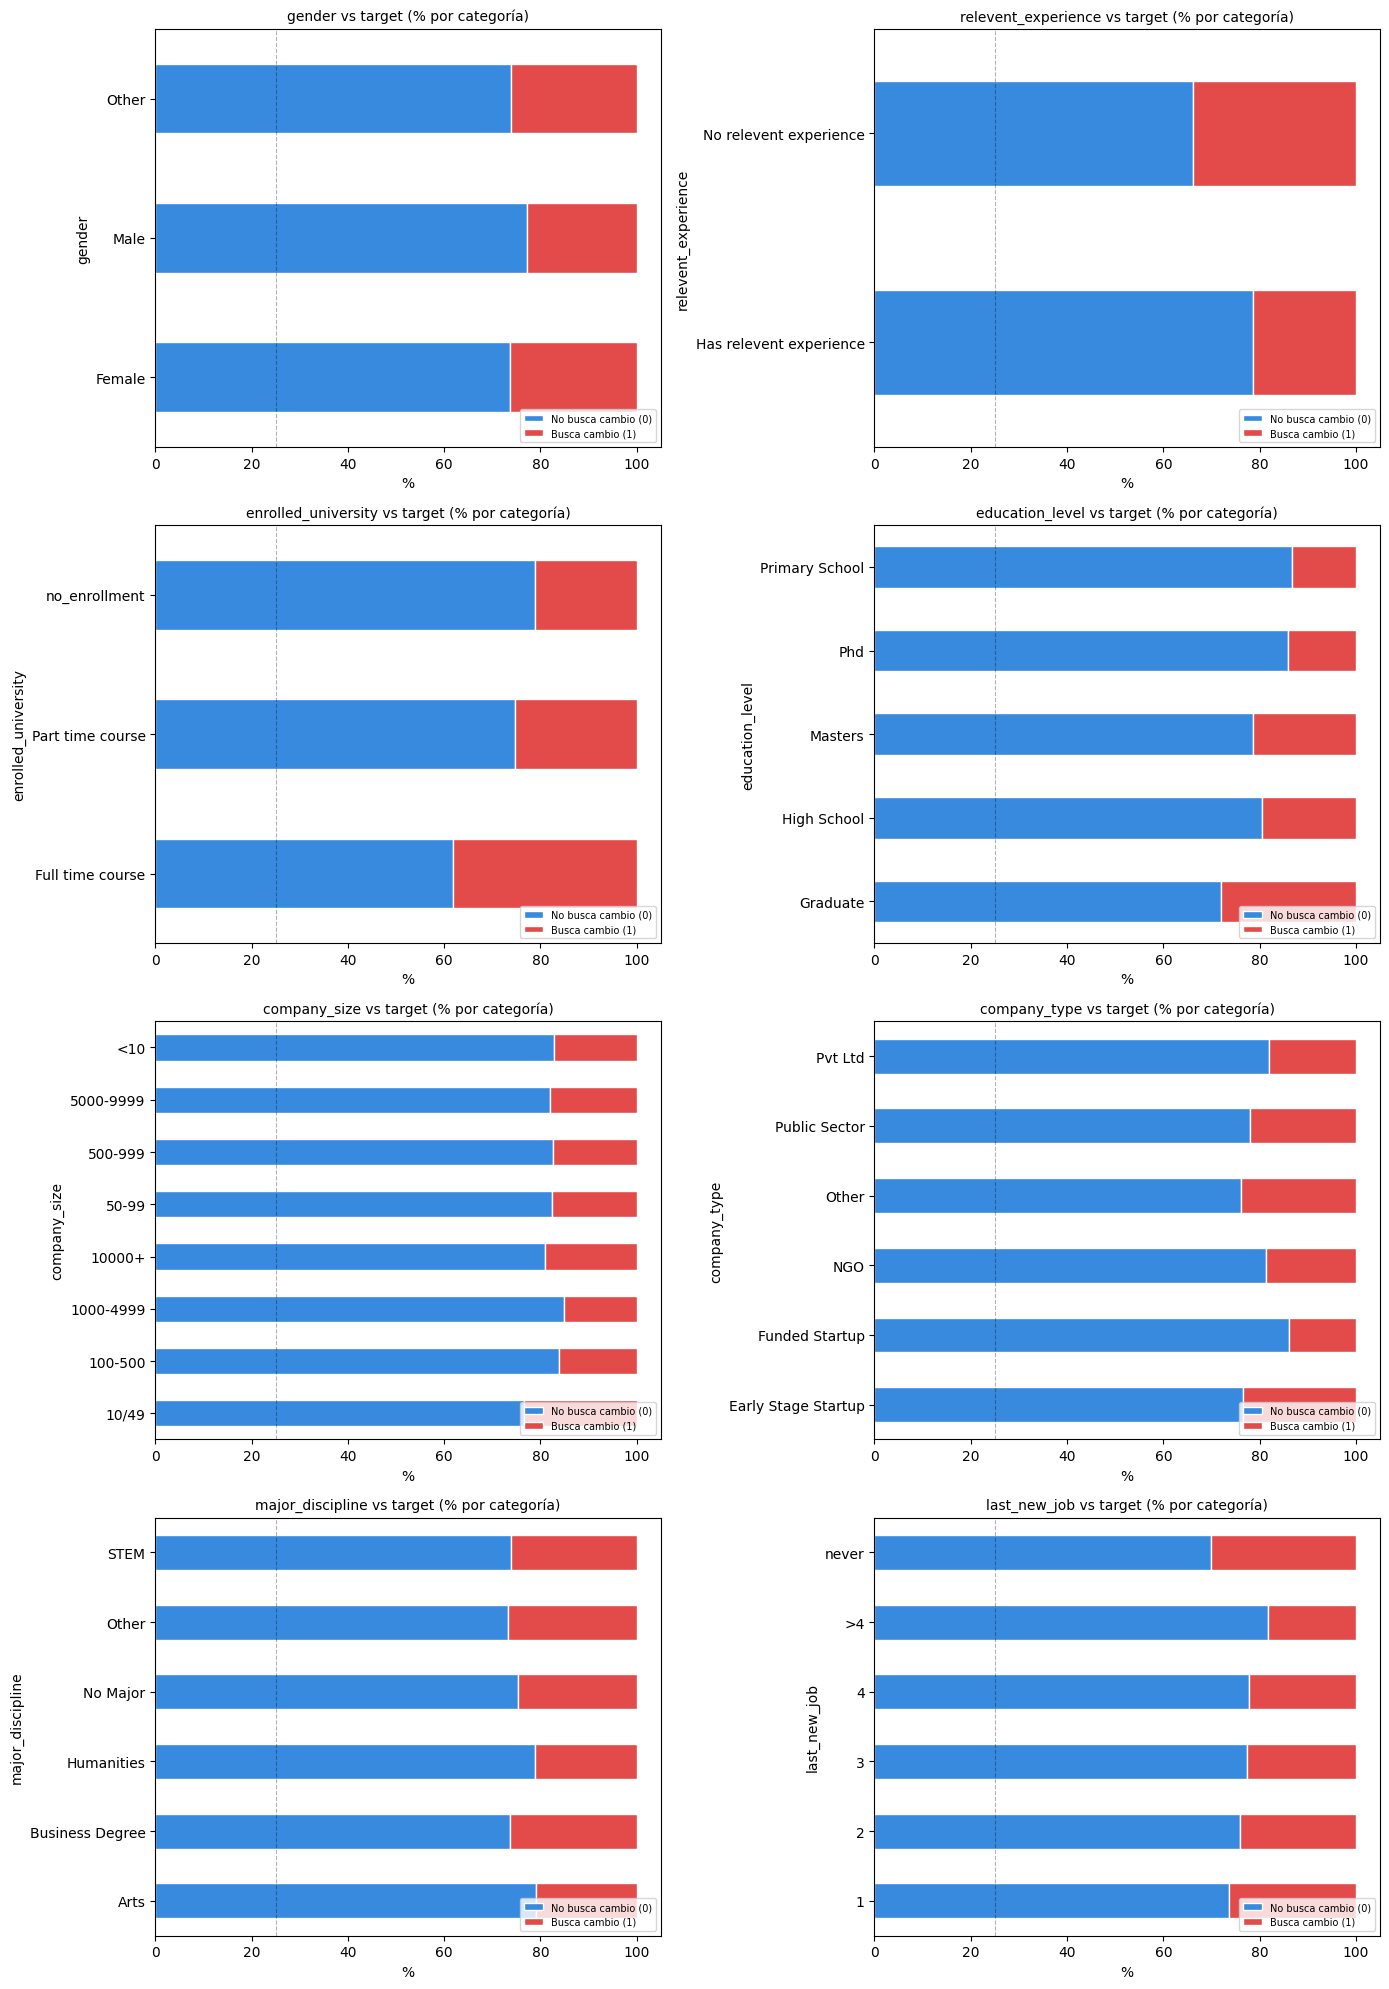

In [116]:
cat_vs_target = [
    'gender', 'relevent_experience', 'enrolled_university',
    'education_level', 'company_size', 'company_type',
    'major_discipline', 'last_new_job'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for i, var in enumerate(cat_vs_target):
    ct = pd.crosstab(data[var], data['target'], normalize='index') * 100
    ct.columns = ['No busca cambio (0)', 'Busca cambio (1)']
    ct.plot(kind='barh', stacked=True, ax=axes[i],
            color=['#378ADD', '#E24B4A'], edgecolor='white')
    axes[i].set_title(f'{var} vs target (% por categoría)', fontsize=10)
    axes[i].set_xlabel('%')
    axes[i].axvline(x=25, color='black', linestyle='--', alpha=0.3, linewidth=0.8)
    axes[i].legend(loc='lower right', fontsize=7)

plt.tight_layout()
plt.show()

chi-cuadrado??? cat vs target? Kruskal-Wallis, no?

Mann-Whitney U para variables numéricas vs target, qué???

---
## 4. Tratamiento de outliers

### ¿Qué hacemos aquí?
Identificamos y eliminamos valores extremos en las variables numéricas usando el método IQR (rango intercuartílico).

### El método IQR
Para cada variable:
- $Q1$ = percentil 25, $Q3$ = percentil 75, $IQR = Q3 - Q1$
- Límite inferior: $Q1 - k \times IQR$
- Límite superior: $Q3 + k \times IQR$
- Se eliminan las **filas** donde cualquier variable supera estos límites

**La elección del factor $k$ es una decisión importante:**
- $k = 1.5$: estándar de Tukey — elimina ~12% de los datos (muy agresivo si los outliers son reales)
- $k = 3$: conservador — elimina solo los extremos verdaderamente anómalos (~5%)

Algo más???

In [117]:
cols_para_outliers = cols_para_outliers = data[['city_development_index', 'training_hours']].columns.tolist()
def calcular_retencion(df, columns, k):
    q1=df[columns].quantile(0.25)
    q3=df[columns].quantile(0.75)
    iqr =q3-q1
    lower =q1-k*iqr
    upper =q3+k*iqr
    mask = ~((df[columns]<lower)|(df[columns]>upper)).any(axis=1)
    return mask.sum(), mask.sum()/len(df) * 100

In [118]:
for k in [1.5,2,2.5,3,3.5]:
    n,pct=calcular_retencion(data, cols_para_outliers, k)
    print(f'{k:>10}|{n:>17}|{pct:>17}%')

       1.5|            18157|94.77502870863347%
         2|            18554|96.84727006994467%
       2.5|            18746|97.84946236559139%
         3|            18883|98.56456832654766%
       3.5|            19043|99.39972857291993%


In [119]:
# Escribe aquí tu código
def remove_outliers_iqr(df, columns, k=3):
    q1=df[columns].quantile(0.25)
    q3=df[columns].quantile(0.75)
    iqr =q3-q1
    lower =q1-k*iqr
    upper =q3+k*iqr
    mask = ~((df[columns]<lower)|(df[columns]>upper)).any(axis=1)
    return df[mask].copy()

data_clean = remove_outliers_iqr(data, cols_para_outliers, k=1.5)

In [ ]:
data_clean

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


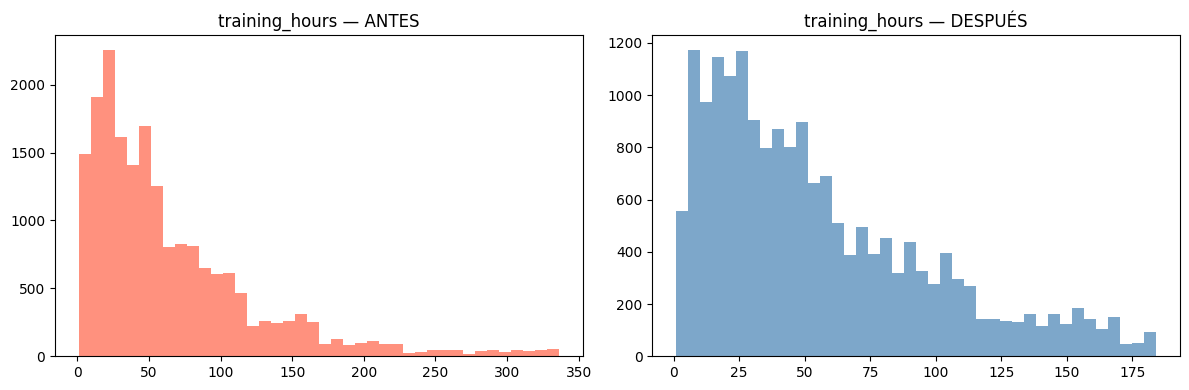

In [ ]:
# Escribe aquí tu código
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(data['training_hours'], bins=40, color='tomato', alpha=0.7)
axes[0].set_title('training_hours — ANTES')
axes[1].hist(data_clean['training_hours'], bins=40, color='steelblue', alpha=0.7)
axes[1].set_title('training_hours — DESPUÉS')
plt.tight_layout()
plt.show()

Repasar tratamiento training_hours???

---
## 5. Imputación de valores perdidos

In [125]:
# ─── Visualización del porcentaje de faltantes ────────────────────────────────
# Un gráfico de barras permite ver de un vistazo qué variables están más afectadas.
# Las líneas de referencia al 50% y 20% ayudan a clasificar la gravedad:
# - >50%: considerar eliminar la columna o crear un indicador binario
# - 20-50%: imputación necesaria, elegir estrategia con cuidado
# - <5%: imputación simple suele ser suficiente

data_clean = data.copy()

# company_size y company_type: nulos indican candidato sin empleo actual
# → categoría propia 'Not employed' (preserva señal informativa)
data_clean['company_size'].fillna('Not employed', inplace=True)
data_clean['company_type'].fillna('Not employed', inplace=True)

#más casos???

# Resto (< 2.5% de nulos): imputación por moda
for col in ['enrolled_university', 'education_level', 'experience', 'last_new_job']:
    moda = data_clean[col].mode()[0]
    data_clean[col].fillna(moda, inplace=True)
    print(f"  {col}: imputado con moda '{moda}'")

print(f'\nNulos restantes: {data_clean.isnull().sum().sum()}')

  enrolled_university: imputado con moda 'no_enrollment'
  education_level: imputado con moda 'Graduate'
  experience: imputado con moda '>20'
  last_new_job: imputado con moda '1'

Nulos restantes: 7321


C:\Users\alejo\AppData\Local\Temp\ipykernel_44776\2023470900.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean['company_size'].fillna('Not employed', inplace=True)
C:\Users\alejo\AppData\Local\Temp\ipykernel_44776\2023470900.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [126]:
data_clean.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Not employed,Not employed,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,Not employed,Not employed,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,no_enrollment,Graduate,Business Degree,<1,Not employed,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


---
## 6. Tratamiento de variables categóricas ???

---
## 7. Feature Engineering ???


---
## 8. Preparación final: OHE, Split y Escalado ???